# 08 — ML Model: Continuous WPA Prediction

Train three XGBoost models (one per decision type: go_for_it, punt, field_goal) that predict
**Win Probability Added (WPA)** for any exact game situation — no bucketing required.

These models power:
- The upgraded 4th Down Decision Calculator (exact situational answers)
- The Decision Boundary Heatmap app (real-time 20×20 grid scoring)

**Temporal train/test split** — train on 1999–2023, evaluate on 2024–2025.
Never use random split; it leaks future data into rolling features.

**Features:** yardline_100, ydstogo, score_differential, game_seconds_remaining, season_norm

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs'
FIG_DIR  = ROOT / 'outputs' / 'figures'
MDL_DIR  = ROOT / 'models'
MDL_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DEC_COLORS = {'go_for_it': '#2E7D32', 'punt': '#546E7A', 'field_goal': '#1565C0'}
DEC_LABELS = {'go_for_it': 'Go For It', 'punt': 'Punt', 'field_goal': 'Field Goal'}
DECISIONS  = ['go_for_it', 'punt', 'field_goal']

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load and prepare data ──────────────────────────────────────────────────────
df = pd.read_parquet(DATA_DIR / 'fourth_downs_graded.parquet')
print(f'Loaded: {len(df):,} plays  |  Seasons: {df["season"].min()}–{df["season"].max()}')

# Drop rows with null WPA (83 plays — penalty/incomplete situations)
df = df.dropna(subset=['wpa'])
print(f'After dropping null WPA: {len(df):,} plays')

# Normalize season to 0–1 so the model learns temporal trends
FIRST, LAST = 1999, 2025
df['season_norm'] = (df['season'] - FIRST) / (LAST - FIRST)

FEATURES = ['yardline_100', 'ydstogo', 'score_differential',
            'game_seconds_remaining', 'season_norm']

print(f'\nFeatures: {FEATURES}')
print('\nDecision counts:')
print(df['decision'].value_counts())
print('\nNull check on features:')
print(df[FEATURES].isnull().sum())

Loaded: 107,189 plays  |  Seasons: 1999–2025
After dropping null WPA: 107,106 plays

Features: ['yardline_100', 'ydstogo', 'score_differential', 'game_seconds_remaining', 'season_norm']

Decision counts:
decision
punt          66137
field_goal    25455
go_for_it     15514
Name: count, dtype: int64

Null check on features:
yardline_100              0
ydstogo                   0
score_differential        0
game_seconds_remaining    0
season_norm               0
dtype: int64


In [3]:
# ── Train / test split ─────────────────────────────────────────────────────────
# Temporal split: train on 1999–2023, test on 2024–2025
# This mimics real deployment — model never sees future seasons during training
TRAIN_END = 2023

train_df = df[df['season'] <= TRAIN_END]
test_df  = df[df['season'] >  TRAIN_END]

print(f'Train: {len(train_df):,} plays  ({train_df["season"].min()}–{train_df["season"].max()})')
print(f'Test:  {len(test_df):,} plays   ({test_df["season"].min()}–{test_df["season"].max()})')
print(f'\nTest decision counts:')
print(test_df['decision'].value_counts())

Train: 99,111 plays  (1999–2023)
Test:  7,995 plays   (2024–2025)

Test decision counts:
decision
punt          4161
field_goal    2087
go_for_it     1747
Name: count, dtype: int64


In [4]:
# ── Model training helper ──────────────────────────────────────────────────────
def train_decision_model(decision, train_df, test_df, features):
    """Train an XGBoost model predicting WPA for a single decision type."""
    tr = train_df[train_df['decision'] == decision]
    te = test_df[test_df['decision']  == decision]

    X_train, y_train = tr[features], tr['wpa']
    X_test,  y_test  = te[features], te['wpa']

    model = XGBRegressor(
        n_estimators      = 400,
        max_depth         = 4,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_weight  = 10,   # prevents overfit on rare situations
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0,
    )
    model.fit(
        X_train, y_train,
        eval_set              = [(X_test, y_test)],
        verbose               = False,
    )

    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)

    print(f'  {DEC_LABELS[decision]:12s} | n_train={len(tr):,}  n_test={len(te):,}  '
          f'RMSE={rmse:.4f}  R²={r2:.3f}')

    return model, {'decision': decision, 'n_train': len(tr), 'n_test': len(te),
                   'rmse': rmse, 'r2': r2}

print('Helper defined.')

Helper defined.


In [5]:
# ── Train all three models ─────────────────────────────────────────────────────
print('Training models (this takes ~1 minute)...\n')

models  = {}
metrics = []

for dec in DECISIONS:
    m, met = train_decision_model(dec, train_df, test_df, FEATURES)
    models[dec]  = m
    metrics.append(met)

metrics_df = pd.DataFrame(metrics).set_index('decision')
print('\nValidation summary (2024–2025 held-out seasons):')
print(metrics_df.to_string())

Training models (this takes ~1 minute)...



  Go For It    | n_train=13,767  n_test=1,747  RMSE=0.0931  R²=0.028


  Punt         | n_train=61,976  n_test=4,161  RMSE=0.0320  R²=0.381


  Field Goal   | n_train=23,368  n_test=2,087  RMSE=0.0666  R²=0.084

Validation summary (2024–2025 held-out seasons):
            n_train  n_test      rmse        r2
decision                                       
go_for_it     13767    1747  0.093098  0.028340
punt          61976    4161  0.032019  0.380780
field_goal    23368    2087  0.066610  0.084073


In [6]:
# ── Save models ────────────────────────────────────────────────────────────────
for dec, model in models.items():
    path = MDL_DIR / f'xgb_{dec}.pkl'
    joblib.dump(model, path)
    print(f'Saved: {path.name}')

print('\nAll models saved to models/')

Saved: xgb_go_for_it.pkl
Saved: xgb_punt.pkl
Saved: xgb_field_goal.pkl

All models saved to models/


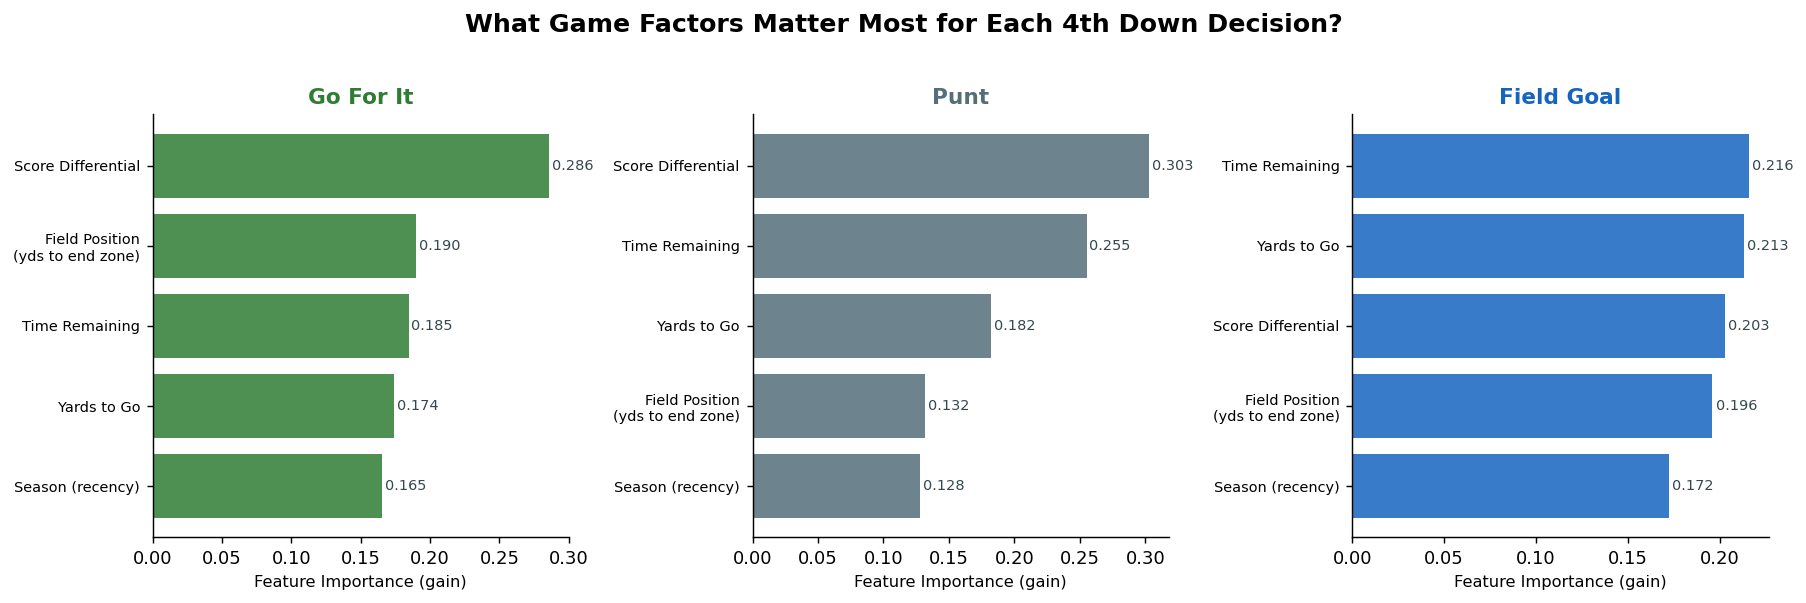

Saved: 23_feature_importance.png


In [7]:
# ── Chart 23: Feature Importance ──────────────────────────────────────────────
FEAT_LABELS = {
    'yardline_100':            'Field Position\n(yds to end zone)',
    'ydstogo':                 'Yards to Go',
    'score_differential':      'Score Differential',
    'game_seconds_remaining':  'Time Remaining',
    'season_norm':             'Season (recency)',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('What Game Factors Matter Most for Each 4th Down Decision?',
             fontsize=14, fontweight='bold', y=1.02)

for ax, dec in zip(axes, DECISIONS):
    model = models[dec]
    imps  = model.feature_importances_
    # Sort descending
    order = np.argsort(imps)
    feat_names = [FEAT_LABELS[FEATURES[i]] for i in order]
    imp_vals   = imps[order]

    bars = ax.barh(feat_names, imp_vals, color=DEC_COLORS[dec], alpha=0.85)
    ax.set_title(DEC_LABELS[dec], fontweight='bold', color=DEC_COLORS[dec], fontsize=12)
    ax.set_xlabel('Feature Importance (gain)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

    # Add value labels
    for bar, val in zip(bars, imp_vals):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color='#37474F')

plt.tight_layout()
plt.savefig(FIG_DIR / '23_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: 23_feature_importance.png')

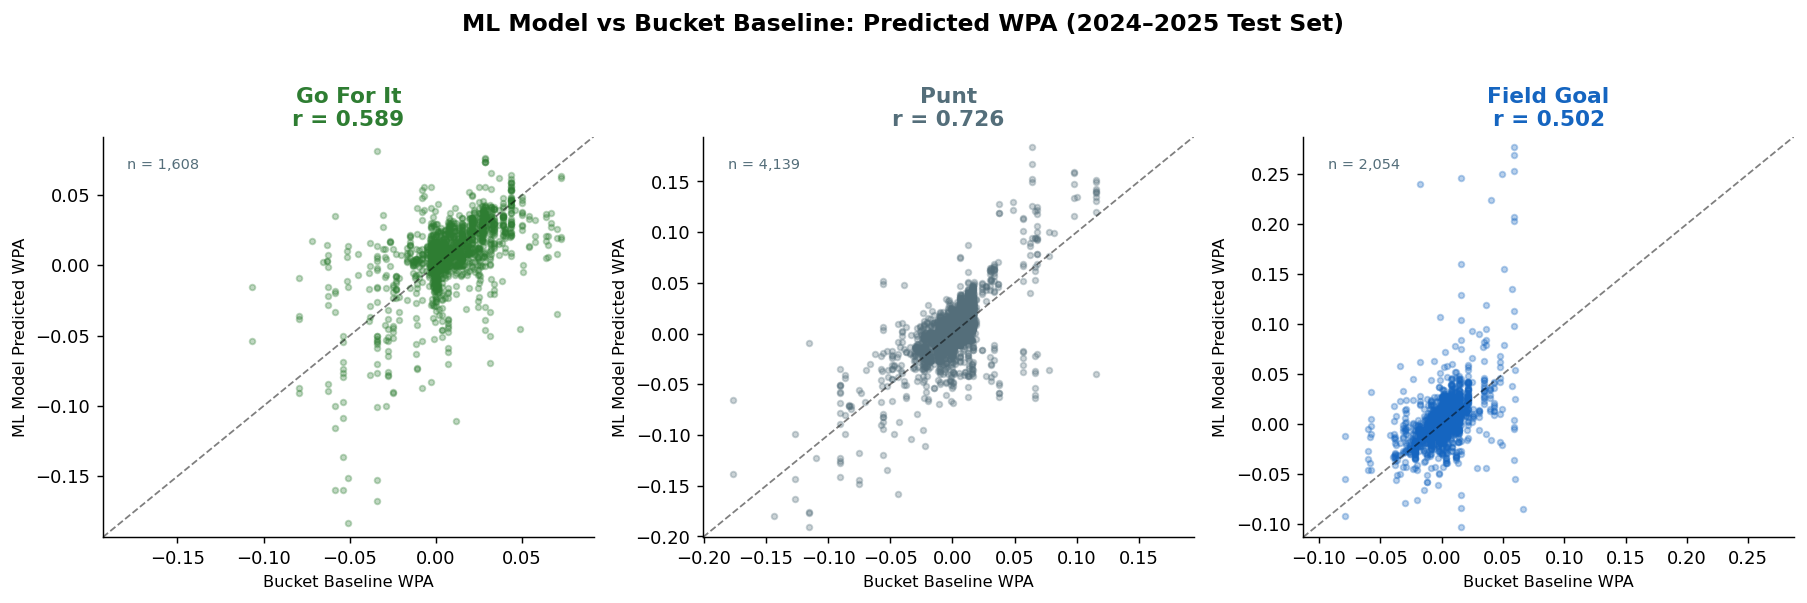

Saved: 24_model_vs_bucket.png


In [8]:
# ── Chart 24: Model vs Bucket Baseline Comparison ─────────────────────────────
# For each play in the test set, compare:
#   - model prediction (continuous)
#   - bucket baseline WPA (from wpa_baselines_4d.csv)

baselines = pd.read_csv(OUT_DIR / 'wpa_baselines_4d.csv')

# Map decision → bucket WPA column
DEC_WPA_COL = {'go_for_it': 'wpa_go', 'punt': 'wpa_punt', 'field_goal': 'wpa_fg'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('ML Model vs Bucket Baseline: Predicted WPA (2024–2025 Test Set)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, dec in zip(axes, DECISIONS):
    te    = test_df[test_df['decision'] == dec].copy()
    preds = models[dec].predict(te[FEATURES])
    te['model_wpa'] = preds

    # Merge bucket baseline
    merged = te.merge(
        baselines[['game_state_key', DEC_WPA_COL[dec]]],
        on='game_state_key', how='inner'
    ).dropna(subset=[DEC_WPA_COL[dec]])

    if merged.empty:
        ax.set_title(f'{DEC_LABELS[dec]}\n(no baseline overlap)')
        continue

    x = merged[DEC_WPA_COL[dec]]
    y = merged['model_wpa']

    ax.scatter(x, y, alpha=0.3, s=10, color=DEC_COLORS[dec])

    # Perfect agreement line
    lim = [min(x.min(), y.min()) - 0.01, max(x.max(), y.max()) + 0.01]
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='Perfect agreement')

    corr = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'{DEC_LABELS[dec]}\nr = {corr:.3f}',
                 fontweight='bold', color=DEC_COLORS[dec])
    ax.set_xlabel('Bucket Baseline WPA', fontsize=9)
    ax.set_ylabel('ML Model Predicted WPA', fontsize=9)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.text(0.05, 0.92, f'n = {len(merged):,}', transform=ax.transAxes,
            fontsize=8, color='#546E7A')

plt.tight_layout()
plt.savefig(FIG_DIR / '24_model_vs_bucket.png', bbox_inches='tight')
plt.show()
print('Saved: 24_model_vs_bucket.png')

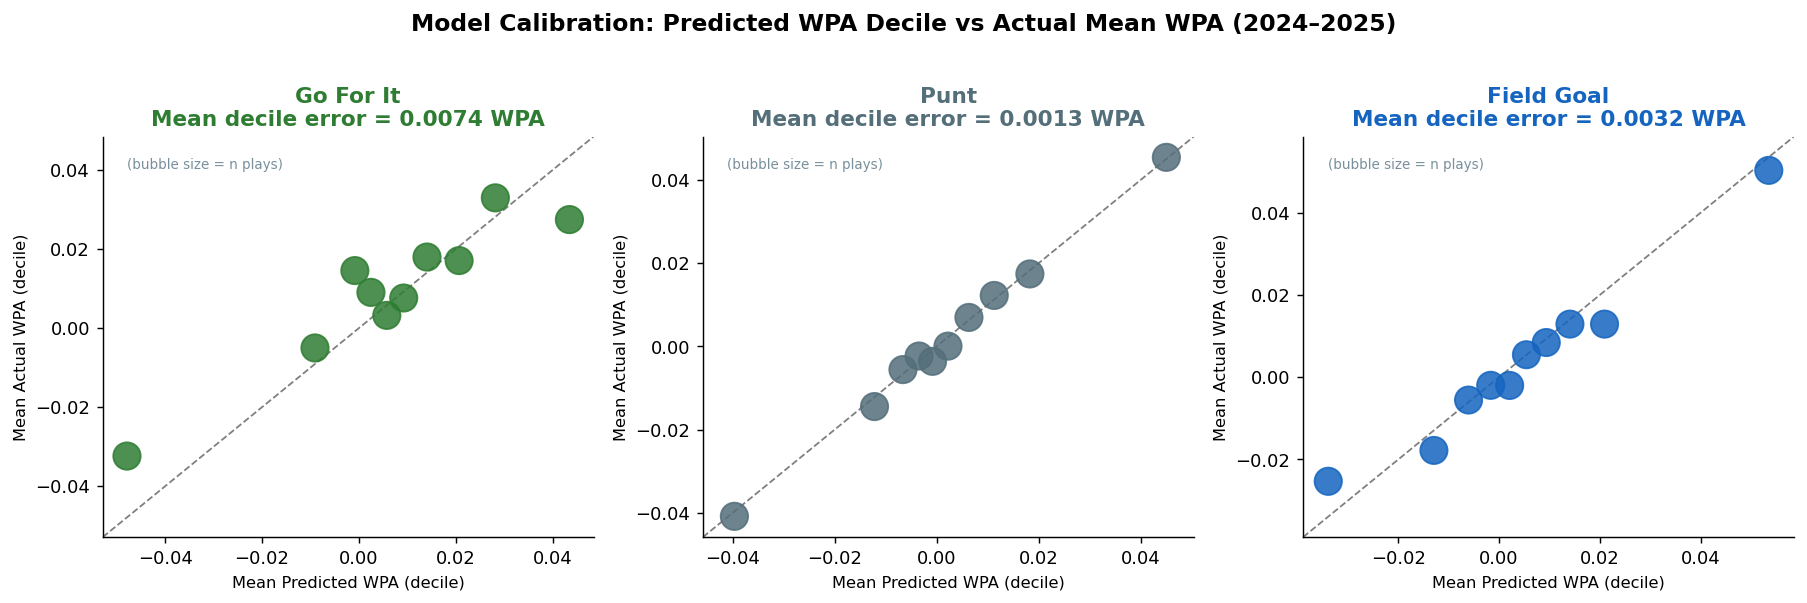

Saved: 25_model_calibration.png


In [9]:
# ── Chart 25: Calibration Plot ─────────────────────────────────────────────────
# Bin predicted WPA into deciles; check whether actual mean WPA matches.
# A well-calibrated model has points close to the diagonal.

N_BINS = 10

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Model Calibration: Predicted WPA Decile vs Actual Mean WPA (2024–2025)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, dec in zip(axes, DECISIONS):
    te    = test_df[test_df['decision'] == dec].copy()
    preds = models[dec].predict(te[FEATURES])
    te['pred_wpa'] = preds

    te['pred_bin'] = pd.qcut(te['pred_wpa'], q=N_BINS, labels=False, duplicates='drop')
    cal = te.groupby('pred_bin').agg(
        mean_pred=('pred_wpa', 'mean'),
        mean_actual=('wpa', 'mean'),
        n=('wpa', 'count')
    ).reset_index()

    ax.scatter(cal['mean_pred'], cal['mean_actual'],
               s=cal['n'] / cal['n'].max() * 200 + 30,
               color=DEC_COLORS[dec], alpha=0.85, zorder=3)

    # Perfect calibration line
    lim = [min(cal['mean_pred'].min(), cal['mean_actual'].min()) - 0.005,
           max(cal['mean_pred'].max(), cal['mean_actual'].max()) + 0.005]
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)

    mae = np.abs(cal['mean_pred'] - cal['mean_actual']).mean()
    ax.set_title(f'{DEC_LABELS[dec]}\nMean decile error = {mae:.4f} WPA',
                 fontweight='bold', color=DEC_COLORS[dec])
    ax.set_xlabel('Mean Predicted WPA (decile)', fontsize=9)
    ax.set_ylabel('Mean Actual WPA (decile)', fontsize=9)
    ax.text(0.05, 0.92, '(bubble size = n plays)', transform=ax.transAxes,
            fontsize=7.5, color='#78909C')

plt.tight_layout()
plt.savefig(FIG_DIR / '25_model_calibration.png', bbox_inches='tight')
plt.show()
print('Saved: 25_model_calibration.png')

In [10]:
# ── Final summary ──────────────────────────────────────────────────────────────
print('=' * 55)
print('MODEL TRAINING COMPLETE')
print('=' * 55)
print(metrics_df[['n_train','n_test','rmse','r2']].round(4).to_string())
print()
print('Saved models:')
for f in sorted(MDL_DIR.glob('*.pkl')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:30s}  {size_kb:.0f} KB')
print()
print('Saved charts:')
for n in ['23_feature_importance.png','24_model_vs_bucket.png','25_model_calibration.png']:
    print(f'  outputs/figures/{n}')

MODEL TRAINING COMPLETE
            n_train  n_test    rmse      r2
decision                                   
go_for_it     13767    1747  0.0931  0.0283
punt          61976    4161  0.0320  0.3808
field_goal    23368    2087  0.0666  0.0841

Saved models:
  xgb_field_goal.pkl              611 KB
  xgb_go_for_it.pkl               638 KB
  xgb_punt.pkl                    657 KB

Saved charts:
  outputs/figures/23_feature_importance.png
  outputs/figures/24_model_vs_bucket.png
  outputs/figures/25_model_calibration.png
